<img src="images/banner.png" style="width: 100%;">

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Density-based Clustering

*References*

[1] C. Aggarwal, Data Mining: The Textbook, Chapter 6.

[2] Han, Jiawei, Jian Pei, and Hanghang Tong. *Data mining: concepts and techniques 4th Edition.* Morgan kaufmann, 2023.

Prepared by **Leodegario Lorenzo II**

## 1 Density-based Clustering Method

To demonstrate how we perform density-based clustering in Python, let's use proceed and use the `Iris` dataset for illustration.

In [2]:
from sklearn.datasets import load_iris

### Data Loading and Preprocessing

In [3]:
data = load_iris(as_frame=True)
print(data['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [4]:
X = (data['data']
     .dropna()
     .astype(float))
X = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0)) # Min-Max Normalization

### Dimensionality Reduction using SVD

In [5]:
from sklearn.decomposition import TruncatedSVD

from utils import plot_energy_ratio

In [6]:
svd = TruncatedSVD(n_components=X.shape[1])
svd.fit(X);

In [7]:
singular_vectors = pd.DataFrame(
    svd.components_, columns=X.columns,
    index=[f'SV {i + 1}' for i in range(X.shape[1])]
)
X_transformed = pd.DataFrame(svd.transform(X), columns=singular_vectors.index)

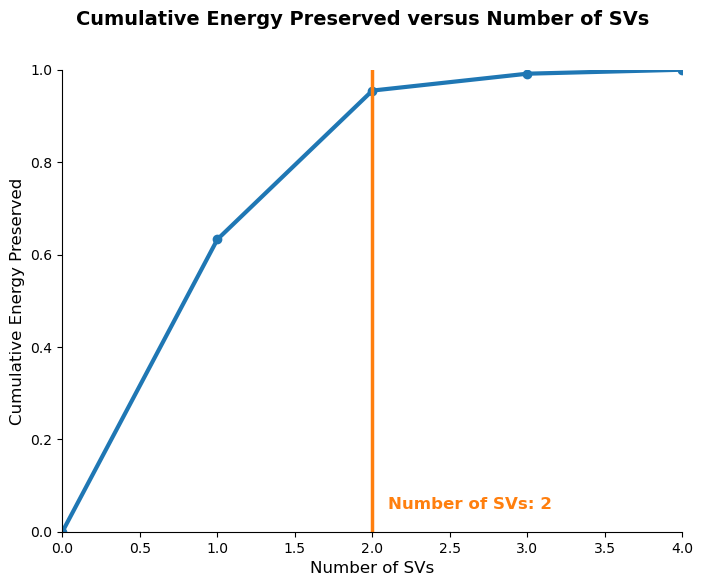

In [8]:
fig, ax, thresh = plot_energy_ratio(svd.explained_variance_ratio_);

In [9]:
X_truncated = X_transformed.iloc[:, :thresh]

In [10]:
from utils import plot_principal_components, plot_clustering

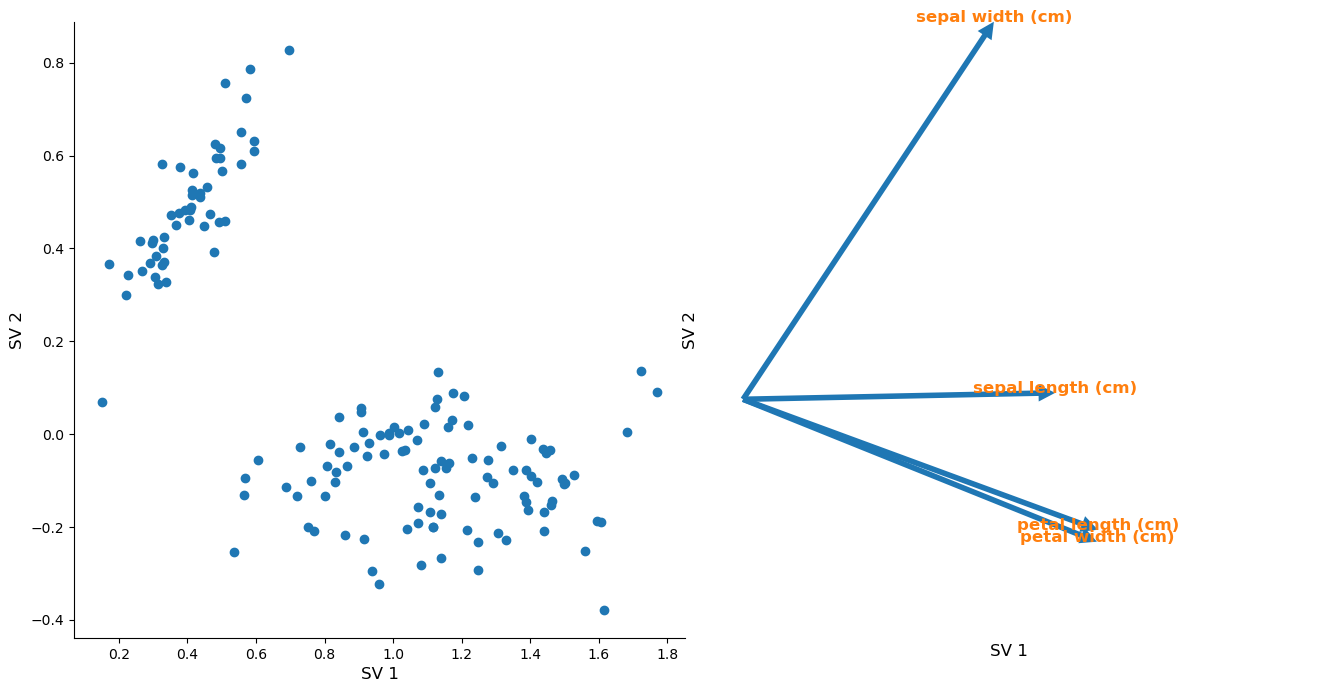

In [11]:
fig, axes = plot_principal_components(X_transformed, singular_vectors, 'SV 1', 'SV 2')
axes[1].set_ylim(singular_vectors.min().min(), singular_vectors.max().max())
axes[1].set_xlim(singular_vectors.min().min() + 0.5, singular_vectors.max().max());

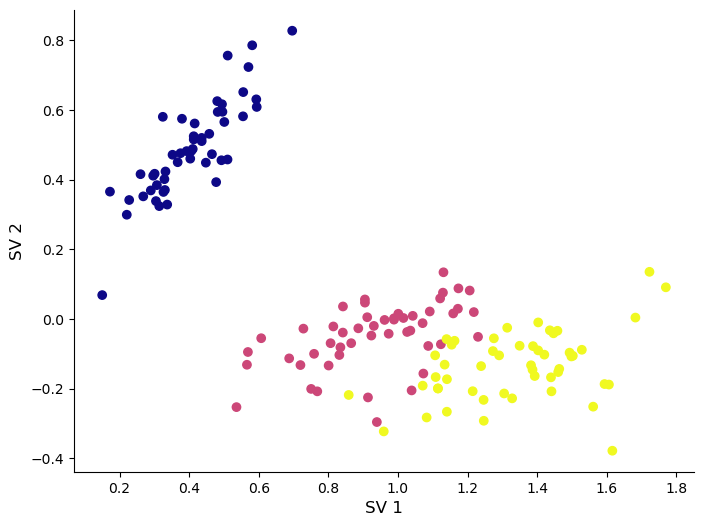

In [12]:
plot_clustering(X_truncated, 'SV 1', 'SV 2', data['target']);

### Clustering Analysis

In `sklearn`, the `DBSCAN` class performs the DBSCAN clustering and it follows the usual fit and predict paradigm.

In [13]:
from sklearn.cluster import DBSCAN

We first fit DBSCAN with some initial parameters to see inspect the results and the effect of the hyperparameters. We set the density threshold $\tau$ to be `5`, expecting that at least for each cluster there would be `10%` core points. We then set the neighborhood radius $\epsilon$ to be `0.2` from visual inspection.

In [14]:
min_samples = 5
eps = 0.2

In [15]:
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan.fit(X)
dbscan_labels = dbscan.labels_

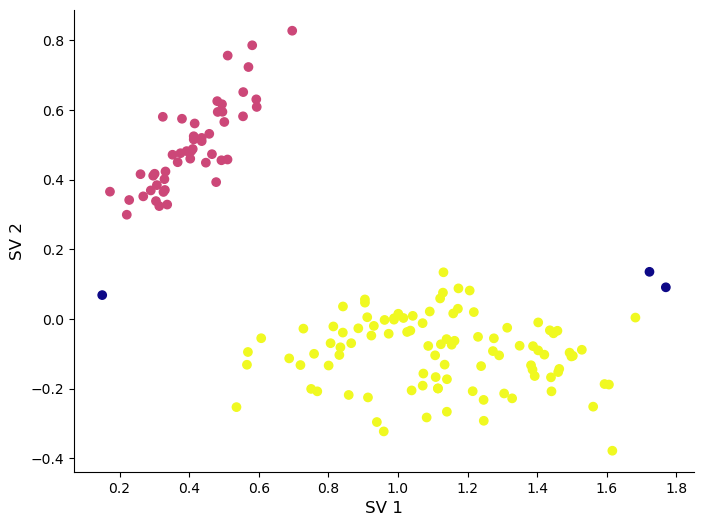

In [16]:
plot_clustering(X_truncated, 'SV 1', 'SV 2', dbscan_labels);

### Determining the neighborhood radius $\epsilon$ 

We've mostly set the DBSCAN parameters $\tau$ and $\epsilon$ via initial estimations. Intuitively, $\tau$ and $\epsilon$ have some relation which can be useful for parameter setting. At the onset, we can set the density threshold $\tau$ based on domain knowledge, then use a value of $\epsilon$ that can capture most of the data points in clusters as core points. We can achieve this by doing the following:

- For each data point, plot the $\tau$-nearest neighbor distance. The majority of the data points inside the clusters will have a small value of $\tau$-nearest neighbor distance. However, the value of $\tau$ will suddenly increase for small number of noisy points. Thus, the key is to identify the tail of distribution of $\tau$-nearest neighbor distances.

We demonstrate how to do this in the following cells using the `NearestNeighbors` object of `sklearn`

In [17]:
from sklearn.neighbors import NearestNeighbors

In [18]:
kneighbors = NearestNeighbors(n_neighbors=min_samples).fit(X)
distances, idx = kneighbors.kneighbors(X)

In [19]:
from utils import plot_neighbor_distances

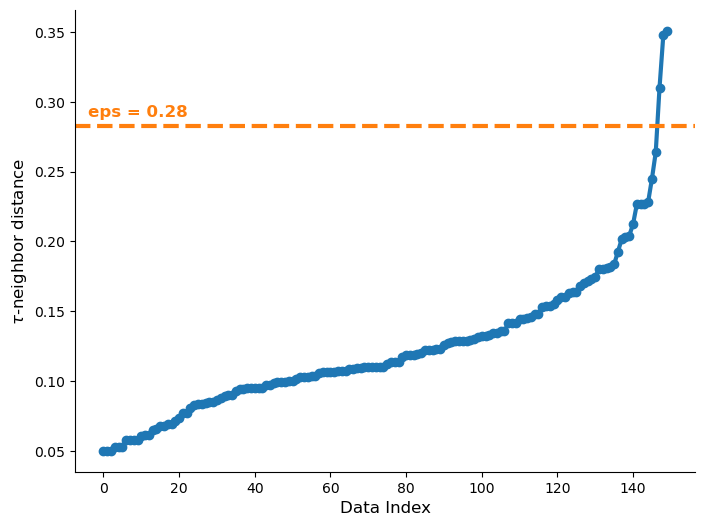

In [20]:
fig, ax, threshold = plot_neighbor_distances(distances[:, min_samples-1])

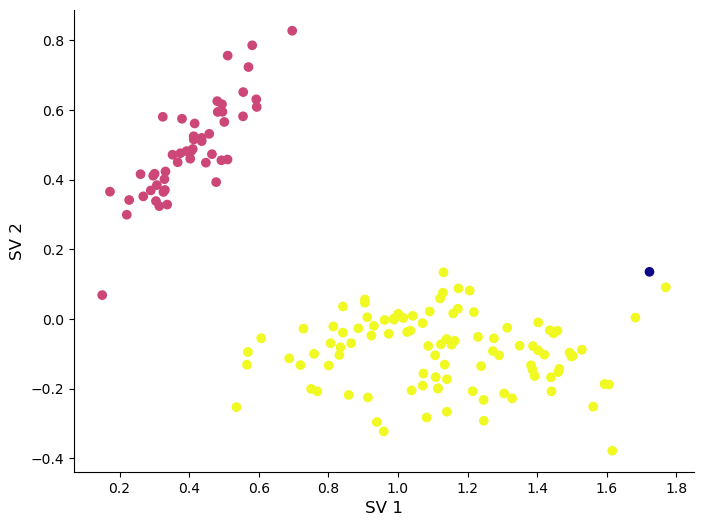

In [21]:
dbscan = DBSCAN(eps=threshold, min_samples=min_samples)
dbscan.fit(X)
dbscan_labels = dbscan.labels_
plot_clustering(X_truncated, 'SV 1', 'SV 2', dbscan_labels);

### Final Clustering

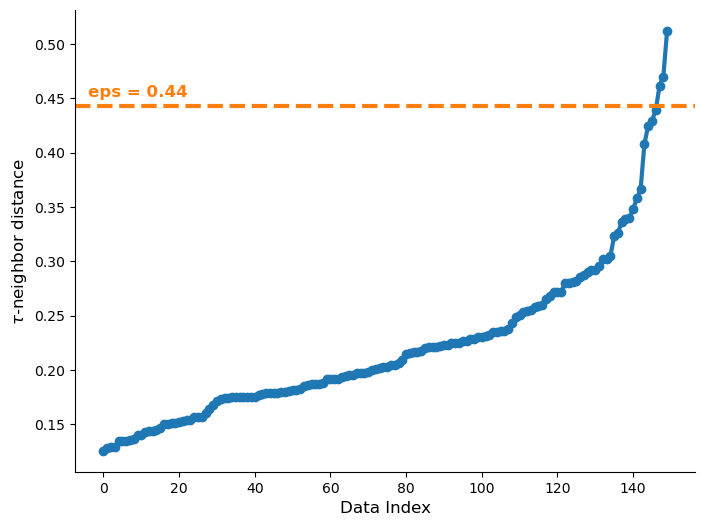

In [22]:
min_samples = 20

kneighbors = NearestNeighbors(n_neighbors=min_samples).fit(X)
distances, idx = kneighbors.kneighbors(X)
fig, ax, threshold = plot_neighbor_distances(distances[:, min_samples-1])

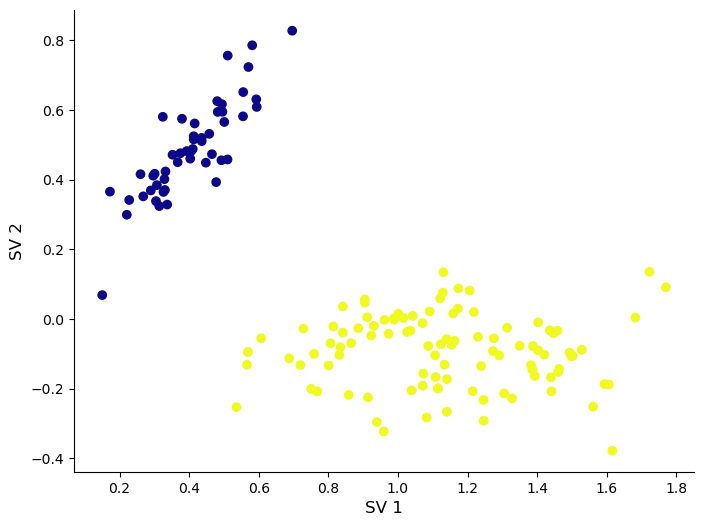

In [23]:
dbscan = DBSCAN(eps=threshold, min_samples=min_samples)
dbscan.fit(X)
dbscan_labels = dbscan.labels_
plot_clustering(X_truncated, 'SV 1', 'SV 2', dbscan_labels);

## 2 Applying Other Clustering Methods

### k-Means

In [24]:
from sklearn.cluster import KMeans

In [25]:
# Set number of trials
num_trials = 10
k_range = range(1, 21)

# Set results container - mean and std of inertias per trial
inertias_mean = []
inertias_std = []
for k in k_range:
    inertias = []
    for i in range(num_trials):
        # Fit and predict for k number of clusters setting
        cur_kmeans = KMeans(n_clusters=k, random_state=i, n_init='auto')
        cluster_labels = cur_kmeans.fit_predict(X)
        inertias.append(cur_kmeans.inertia_)
    inertias_mean.append(np.mean(inertias))
    inertias_std.append(np.std(inertias))
inertias_mean = np.array(inertias_mean)
inertias_std = np.array(inertias_std)

In [26]:
from utils import plot_internal_metric

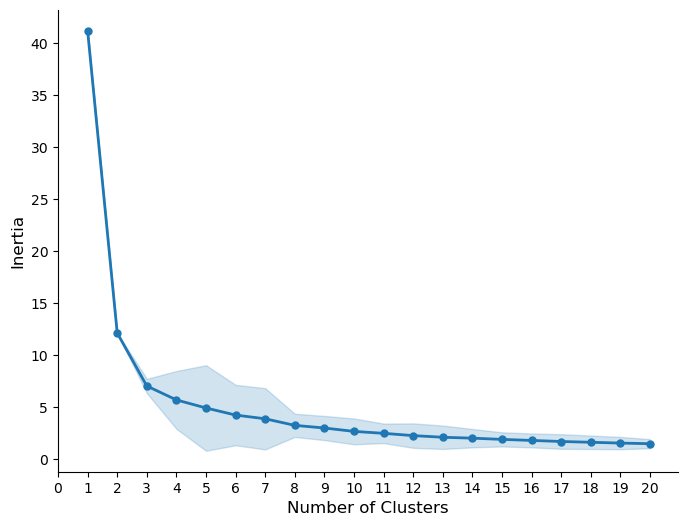

In [27]:
plot_internal_metric(k_range, inertias_mean, inertias_std, 'Inertia',
                     ebar_scale=10);

In [28]:
# Hyperparameters
num_trials = 20
k = 3

inertias = []
for i in range(num_trials):
    cur_kmeans = KMeans(n_clusters=k, random_state=i, n_init='auto')
    cluster_labels = cur_kmeans.fit_predict(X)
    inertias.append(cur_kmeans.inertia_)

# Optimal setting
kmeans = KMeans(n_clusters=k, random_state=np.argmin(inertias), n_init='auto')
kmeans_labels = kmeans.fit_predict(X)

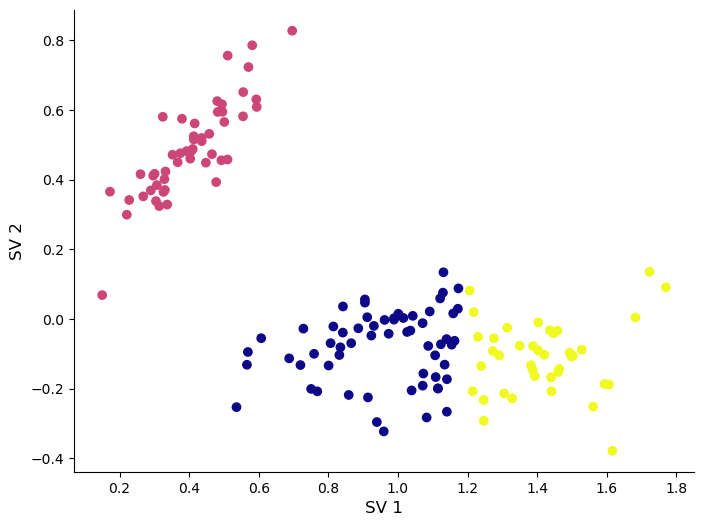

In [29]:
plot_clustering(X_truncated, 'SV 1', 'SV 2', kmeans_labels);

### Ward's Method

In [30]:
from scipy.cluster.hierarchy import linkage, dendrogram

In [31]:
Z_ward = linkage(X, method='ward', optimal_ordering=True)

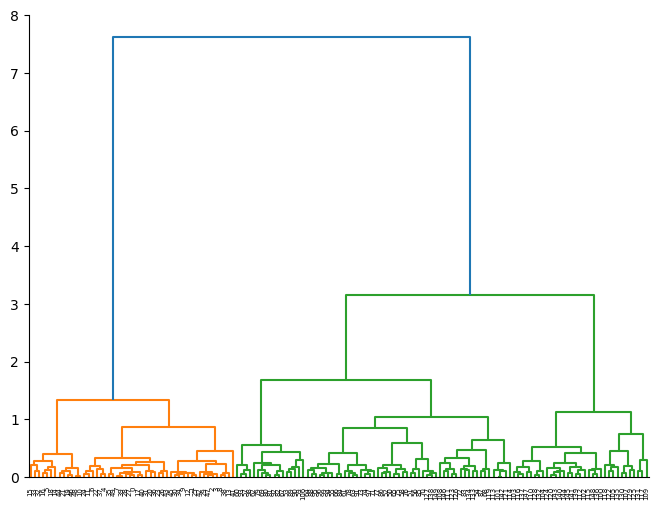

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))
ward_dendrogram = dendrogram(Z_ward, ax=ax)
ax.spines[['top', 'right']].set_visible(False);

In [33]:
from scipy.cluster.hierarchy import cut_tree

In [34]:
ward_labels = cut_tree(Z_ward, n_clusters=3).flatten()

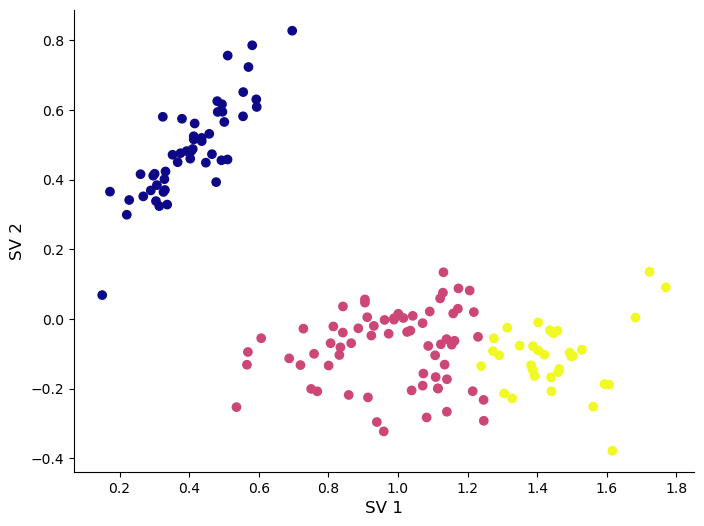

In [35]:
plot_clustering(X_truncated, 'SV 1', 'SV 2', ward_labels);

## 3 Cluster Evaluation

### Internal Validation Metrics

In [36]:
from sklearn.metrics import calinski_harabasz_score, silhouette_score, davies_bouldin_score

In [37]:
def compute_inertia(X, cluster_labels):
    return X.groupby(cluster_labels).apply(lambda x: (x - x.mean())**2).sum().sum()

In [38]:
internal_validation_metrics = {
    'Inertia': compute_inertia,
    'CH Score': calinski_harabasz_score,
    'Silhouette Score': silhouette_score,
    'DB Index': davies_bouldin_score
}
clusterings = {
    'DBSCAN': dbscan_labels,
    'k-Means': kmeans_labels,
    'Ward': ward_labels
}

In [39]:
result = {}
for clustering in clusterings:
    result[clustering] = {}
    for metric in internal_validation_metrics:
        result[clustering][metric] = internal_validation_metrics[metric](X, clusterings[clustering])

In [40]:
pd.DataFrame(result)

,DBSCAN,k-Means,Ward
Inertia,12.127791,6.982216,7.157136
CH Score,354.365556,359.845074,349.254185
Silhouette Score,0.630047,0.504769,0.504800
DB Index,0.486167,0.760277,0.747977


### External Validation Metrics

In [41]:
ground_truth = data['target'].to_numpy()

In [42]:
from sklearn.metrics import jaccard_score
from extrinsic_metrics import compute_purity, compute_entropy, compute_pairwise_score

In [43]:
external_validation_metrics = {
    'Purity': compute_purity,
    'Entropy': compute_entropy,
    'Pairwise-Score': lambda x, y: compute_pairwise_score(x, y, jaccard_score)
}

In [44]:
extrinsic_result = {}
for clustering in clusterings:
    extrinsic_result[clustering] = {}
    for metric in external_validation_metrics:
        extrinsic_result[clustering][metric] = external_validation_metrics[metric](
            ground_truth, clusterings[clustering])

In [45]:
pd.DataFrame(extrinsic_result)

,DBSCAN,k-Means,Ward
Purity,0.666667,0.886667,0.886667
Entropy,0.462098,0.289573,0.252991
Pairwise-Score,0.595142,0.682279,0.688177


<img src="images/banner-down.png" style="width: 100%;">